In [ ]:
!pip install spacy

In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 40.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import json
import numpy as np
import pandas as pd
import re  # text process
import nltk
import spacy
import string
import unicodedata
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.decomposition import NMF
from pprint import pprint
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier
from itertools import cycle
import itertools
import joblib
!pip install gensim
import gensim
from gensim.models import Nmf
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.7 MB/s eta 0:00:00


In [ ]:
nlp = spacy.load('en_core_web_sm')

Load Data

In [ ]:
json_file_path = "complaints.json"

with open(json_file_path, "r") as json_file:
    complaints_data = json.load(json_file)
    complaints_df = pd.json_normalize(complaints_data)

complaints_df.head()

,_index,_type,_id,_score,_source.tags,_source.zip_code,_source.complaint_id,_source.issue,_source.date_received,_source.state,...,_source.company_response,_source.company,_source.submitted_via,_source.date_sent_to_company,_source.company_public_response,_source.sub_product,_source.timely,_source.complaint_what_happened,_source.sub_issue,_source.consumer_consent_provided
0,complaint-public-v2,complaint,3211475,0.0,None,90301,3211475,Attempts to collect debt not owed,2019-04-13T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-13T12:00:00-05:00,None,Credit card debt,Yes,,Debt is not yours,Consent not provided
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Credit card debt,Yes,Good morning my name is XXXX XXXX and I apprec...,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Problem with rewards from credit card,Consent provided
3,complaint-public-v2,complaint,2673060,0.0,None,48066,2673060,Trouble during payment process,2017-09-13T12:00:00-05:00,MI,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2017-09-14T12:00:00-05:00,None,Conventional home mortgage,Yes,,None,Consent not provided
4,complaint-public-v2,complaint,3203545,0.0,None,10473,3203545,Fees or interest,2019-04-05T12:00:00-05:00,NY,...,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2019-04-05T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,,Charged too much interest,N/A


Data Exploartion and Preparation

In [ ]:
complaints_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21324 entries, 0 to 21323
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   _index                             21324 non-null  object 
 1   _type                              21324 non-null  object 
 2   _id                                21324 non-null  object 
 3   _score                             21324 non-null  float64
 4   _source.tags                       3118 non-null   object 
 5   _source.zip_code                   18918 non-null  object 
 6   _source.complaint_id               21324 non-null  object 
 7   _source.issue                      21324 non-null  object 
 8   _source.date_received              21324 non-null  object 
 9   _source.state                      20547 non-null  object 
 10  _source.consumer_disputed          21324 non-null  object 
 11  _source.product                    21324 non-null  obj

In [ ]:
complaints_df.describe()

,_score
count,21324.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [ ]:
complaints_df.describe()

,count,unique,top,freq
_index,21324,1,complaint-public-v2,21324
_type,21324,1,complaint,21324
_id,21324,21324,3348218,1
_source.tags,3118,3,Older American,1512
_source.zip_code,18918,5635,606XX,162
_source.complaint_id,21324,21324,3348218,1
_source.issue,21324,138,Managing an account,3262
_source.date_received,21324,2911,2021-03-09T12:00:00-05:00,33
_source.state,20547,57,CA,3847
_source.consumer_disputed,21324,3,N/A,15833


In [ ]:
complaints_df.columns

Index(['_index', '_type', '_id', '_score', '_source.tags', '_source.zip_code',
       '_source.complaint_id', '_source.issue', '_source.date_received',
       '_source.state', '_source.consumer_disputed', '_source.product',
       '_source.company_response', '_source.company', '_source.submitted_via',
       '_source.date_sent_to_company', '_source.company_public_response',
       '_source.sub_product', '_source.timely',
       '_source.complaint_what_happened', '_source.sub_issue',
       '_source.consumer_consent_provided'],
      dtype='object')

In [ ]:
def rename_columns(column_name):
    if column_name.startswith('_source.'):
        return column_name[len('_source.'):]
    elif column_name.startswith('_'):
        return column_name[1:]
    return column_name
complaints_df.columns = [rename_columns(col) for col in complaints_df.columns]
complaints_df.columns

Index(['index', 'type', 'id', 'score', 'tags', 'zip_code', 'complaint_id',
       'issue', 'date_received', 'state', 'consumer_disputed', 'product',
       'company_response', 'company', 'submitted_via', 'date_sent_to_company',
       'company_public_response', 'sub_product', 'timely',
       'complaint_what_happened', 'sub_issue', 'consumer_consent_provided'],
      dtype='object')

In [ ]:
#filter out rows where 'complaint_what_happened' is either blank or NaN
complaints_df = complaints_df[complaints_df['complaint_what_happened'].replace('', np.nan).notnull()]

In [ ]:
complaints_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7235 entries, 1 to 21322
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   index                      7235 non-null   object 
 1   type                       7235 non-null   object 
 2   id                         7235 non-null   object 
 3   score                      7235 non-null   float64
 4   tags                       1315 non-null   object 
 5   zip_code                   5661 non-null   object 
 6   complaint_id               7235 non-null   object 
 7   issue                      7235 non-null   object 
 8   date_received              7235 non-null   object 
 9   state                      7173 non-null   object 
 10  consumer_disputed          7235 non-null   object 
 11  product                    7235 non-null   object 
 12  company_response           7235 non-null   object 
 13  company                    7235 non-null   object 
 

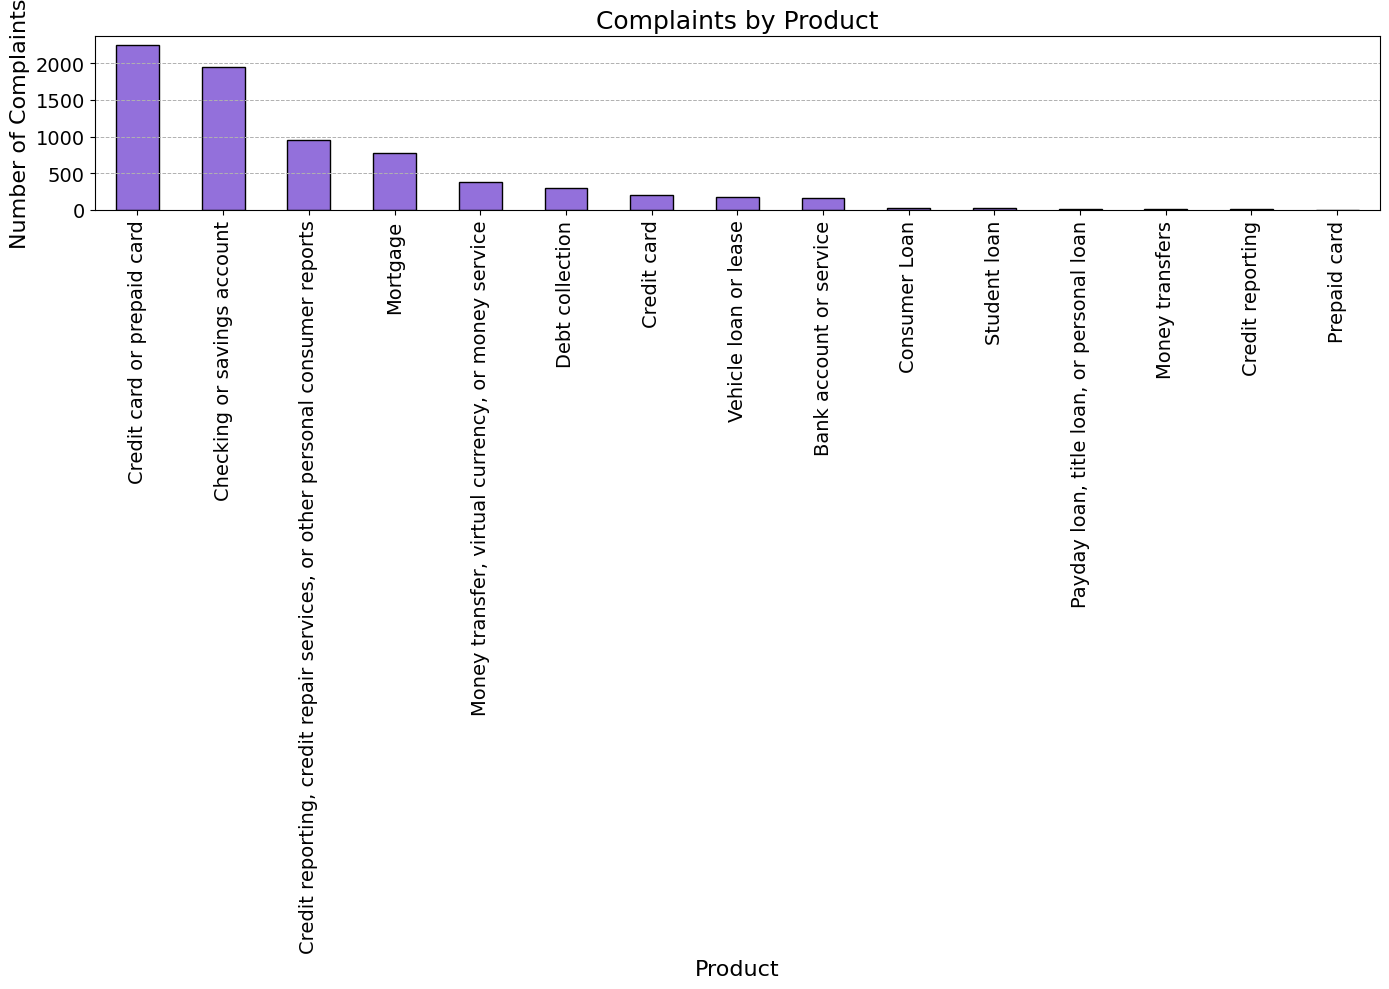

In [ ]:
product_complaints = complaints_df['product'].value_counts()

plt.figure(figsize=(14, 10))
product_complaints.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Complaints by Product', fontsize=18)
plt.xlabel('Product', fontsize=16)
plt.ylabel('Number of Complaints', fontsize=16)
plt.grid(axis='y', linestyle='--', linewidth=0.7)
plt.xticks(rotation=90, fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

#### **Data Preparation**


In [ ]:
def preprocess_text(text):
    """
    Preprocesses the text by converting to lowercase, removing text within square brackets,
    eliminating punctuation, and discarding words with numbers.
    """
    text = text.lower()
    text = re.sub(r'\[.*?]', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\w*\d\w*', ' ', text)
    return text.strip()

def apply_lemmatization(text_list):
    """
    Applies lemmatization to a list of text strings, excluding stopwords and punctuation.
    """
    lemmatized_texts = []
    for doc in tqdm(nlp.pipe(text_list), total=len(text_list)):
        lemmatized_texts.append(' '.join(token.lemma_ for token in doc if not token.is_stop and not token.is_punct))
    return lemmatized_texts

def filter_nouns(text_list):
    """
    Filters and returns only the nouns from a list of text strings.
    """
    noun_texts = []
    for doc in tqdm(nlp.pipe(text_list), total=len(text_list)):
        noun_texts.append(' '.join(token.text for token in doc if token.pos_ == 'NOUN'))
    return noun_texts

In [ ]:
processed_df = pd.DataFrame()

# Preprocess the text data
processed_df['complaint_processed'] = [preprocess_text(text) for text in tqdm(complaints_df['complaint_what_happened'])]

100%|██████████| 7235/7235 [00:05<00:00, 1243.51it/s]


In [ ]:
# Apply lemmatization on the processed text
processed_df['complaint_lemmatized'] = apply_lemmatization(processed_df['complaint_processed'])

100%|██████████| 7235/7235 [03:53<00:00, 30.93it/s]


In [ ]:
# Filter nouns from the lemmatized text
processed_df['complaint_nouns'] = filter_nouns(processed_df['complaint_lemmatized'])

100%|██████████| 7235/7235 [01:50<00:00, 65.21it/s]


In [ ]:
# Display the initial rows of the processed dataframe
processed_df.head()

,complaint_processed,complaint_lemmatized,complaint_nouns
0,good morning my name is xxxx xxxx and i appreciate it if you could help me put a stop to chase bank cardmember services \nin i wrote to chase asking for debt verification and what they sent me a statement which is not acceptable i am asking the bank to validate the debt instead i been receiving mail every month from them attempting to collect a debt \ni have a right to know this information as a consumer \n\nchase account xxxx xxxx xxxx xxxx thanks in advance for your help,good morning xxxx xxxx appreciate help stop chase bank cardmember service \n write chase ask debt verification send statement acceptable ask bank validate debt instead receive mail month attempt collect debt \n right know information consumer \n\n chase account xxxx xxxx xxxx xxxx thank advance help,morning help chase debt verification statement bank validate debt mail month attempt debt information consumer chase account advance help
1,i upgraded my xxxx xxxx card in xx xx and was told by the agent who did the upgrade my anniversary date would not change it turned the agent was giving me the wrong information in order to upgrade the account xxxx changed my anniversary date from xx xx xxxx to xx xx xxxx without my consent xxxx has the recording of the agent who was misled me,upgrade xxxx xxxx card xx xx tell agent upgrade anniversary date change turn agent give wrong information order upgrade account xxxx change anniversary date xx xx xxxx xx xx xxxx consent xxxx recording agent mislead,agent anniversary date change agent information order account change anniversary date agent mislead
2,chase card was reported on xx xx however fraudulent application have been submitted my identity without my consent to fraudulently obtain services do not extend credit without verifying the identity of the applicant,chase card report xx xx fraudulent application submit identity consent fraudulently obtain service extend credit verify identity applicant,card application identity consent service credit verify identity applicant
3,on xx xx while trying to book a xxxx xxxx ticket i came across an offer for to be applied towards the ticket if i applied for a rewards card i put in my information for the offer and within less than a minute was notified via the screen that a decision could not be made i immediately contacted xxxx and was referred to chase bank i then immediately contacted chase bank within no more than of getting the notification on the screen and i was told by the chase representative i spoke with that my application was denied but she could not state why i asked for more information about the xxxx offer and she explained that even if i had been approved the credit offer only gets applied after the first account statement and could not be used to purchase the ticket i then explicitly told her i was glad i got denied and i was absolutely no longer interested in the account i asked that the application be withdrawn and the representative obliged this all happened no later than after putting in the application on xx xx notwithstanding my explicit request not to proceed with the application and contrary to what i was told by the chase representative chase did in fact go ahead to open a credit account in my name on xx xx this is now being reported in my credit report and chase has refused to correct this information on my credit report even though they went ahead to process an application which i did not consent to and out of their error,xx xx try book xxxx xxxx ticket come offer apply ticket apply reward card information offer minute notify screen decision immediately contact xxxx refer chase bank immediately contact chase bank get notification screen tell chase representative speak application deny state ask information xxxx offer explain approve credit offer get apply account statement purchase ticket explicitly tell glad get deny absolutely long interested account ask application withdraw representative obli

**Word Cloud**

In [ ]:
all_nouns = ' '.join(processed_df['complaint_nouns'])

wordcloud = WordCloud(max_words=50, background_color='white', colormap='viridis',
                      contour_color='steelblue', contour_width=2).generate(all_nouns)


In [ ]:
#print the top 70 words
top_50_words = list(wordcloud.words_.keys())[:50]
print(top_50_words)

['chase', 'credit card', 'time', 'account', 'payment', 'bank', 'day', 'information', 'transaction', 'charge', 'state', 'money', 'request', 'year', 'month', 'issue', 'company', 'letter', 'contact', 'credit report', 'loan', 'claim', 'work', 'check', 'email', 'purchase', 'dispute', 'point', 'call', 'chase credit', 'help', 'account chase', 'week', 'person', 'process', 'case', 'fraud', 'customer service', 't', 'date', 'pay', 'phone', 'notice', 'reason', 'chase bank', 'document', 'call chase', 'way', 'order', 'today']


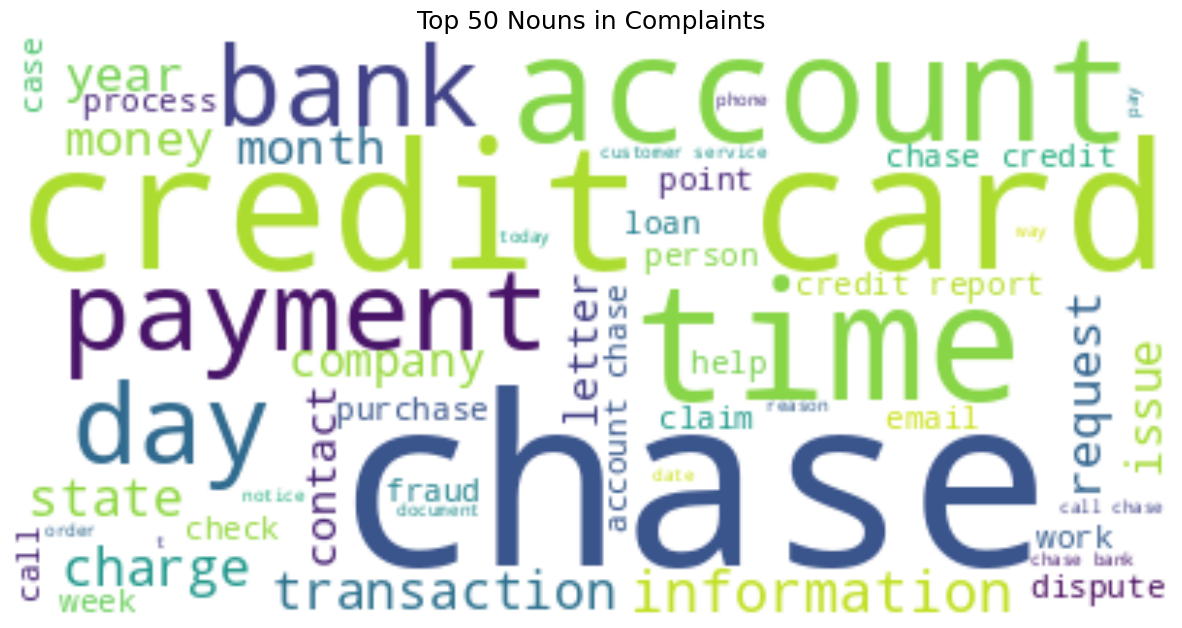

In [ ]:
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Top 50 Nouns in Complaints', fontsize=18)
plt.axis('off')
plt.show()

In [ ]:
processed_df['complaint_cleaned'] = processed_df['complaint_nouns'].apply(lambda x: x.replace('-PRON-', ''))

Top 30 unigram frequency among the complaints

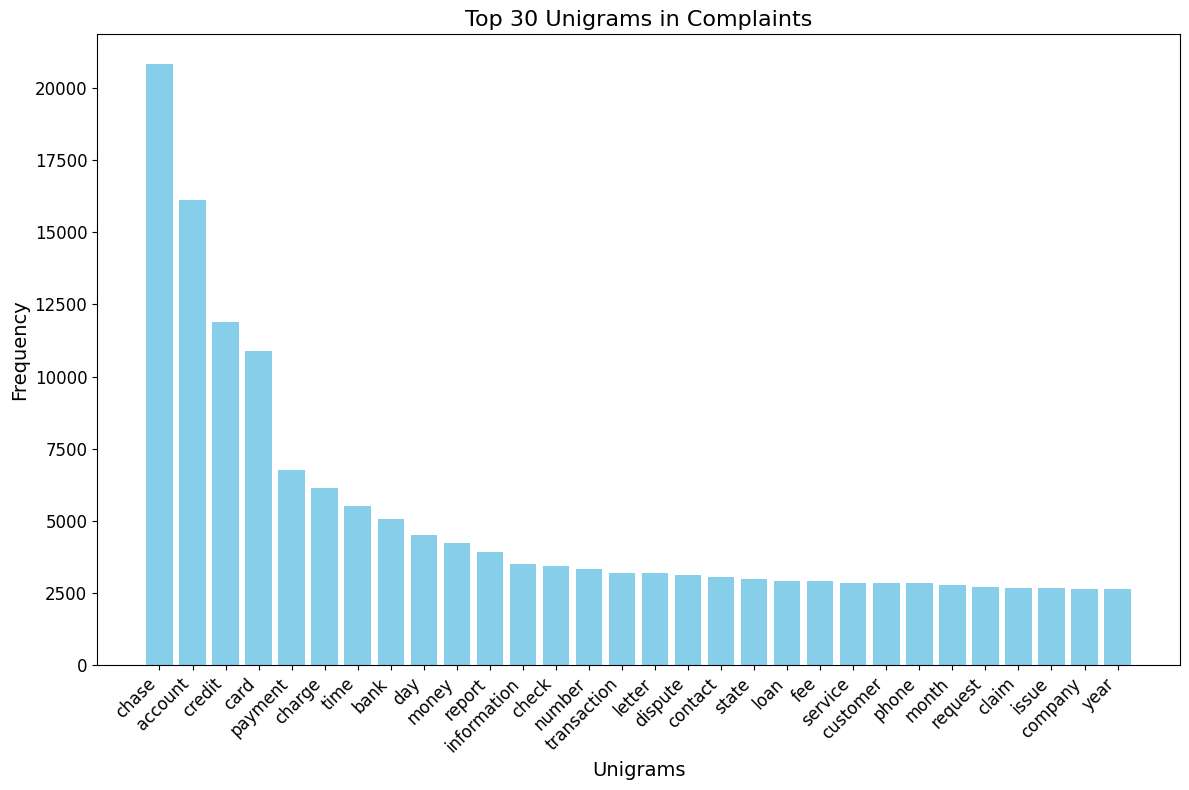

In [ ]:
all_complaints = ' '.join(processed_df['complaint_cleaned'])

def get_top_n_words(corpus, n=None):
    vec = CountVectorizer(stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

common_unigrams = get_top_n_words([all_complaints], 30)
df_unigram = pd.DataFrame(common_unigrams, columns=['unigram', 'count'])

plt.figure(figsize=(12, 8))
plt.bar(df_unigram['unigram'], df_unigram['count'], color='skyblue')
plt.xlabel('Unigrams', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Top 30 Unigrams in Complaints', fontsize=16)
plt.xticks(rotation=45, fontsize=12, ha='right')
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

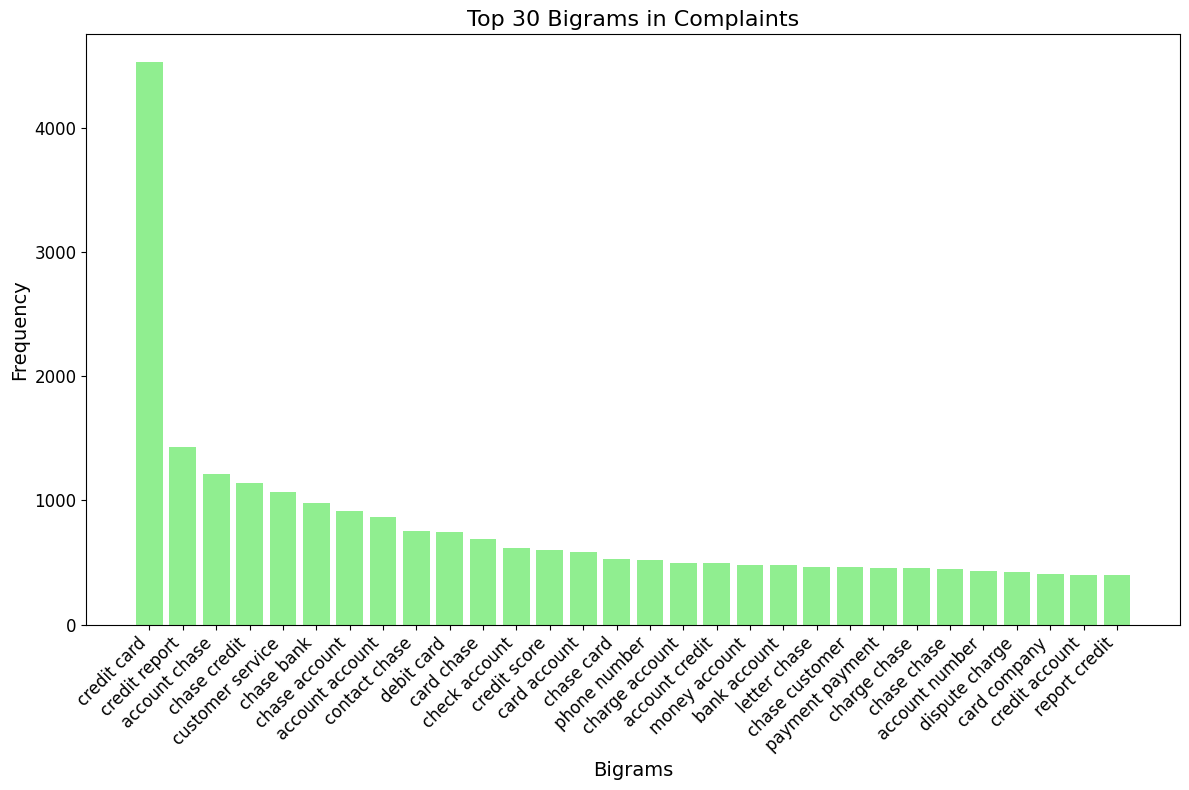

In [ ]:
# Function to get the top n bigrams by frequency
def get_top_n_bigram(corpus, n=None):
    vec = CountVectorizer(stop_words='english', ngram_range=(2, 2)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

common_bigrams = get_top_n_bigram([all_complaints], 30)
df_bigram = pd.DataFrame(common_bigrams, columns=['bigram', 'count'])

plt.figure(figsize=(12, 8))
plt.bar(df_bigram['bigram'], df_bigram['count'], color='lightgreen')
plt.xlabel('Bigrams', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Top 30 Bigrams in Complaints', fontsize=16)
plt.xticks(rotation=45, fontsize=12, ha='right')
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

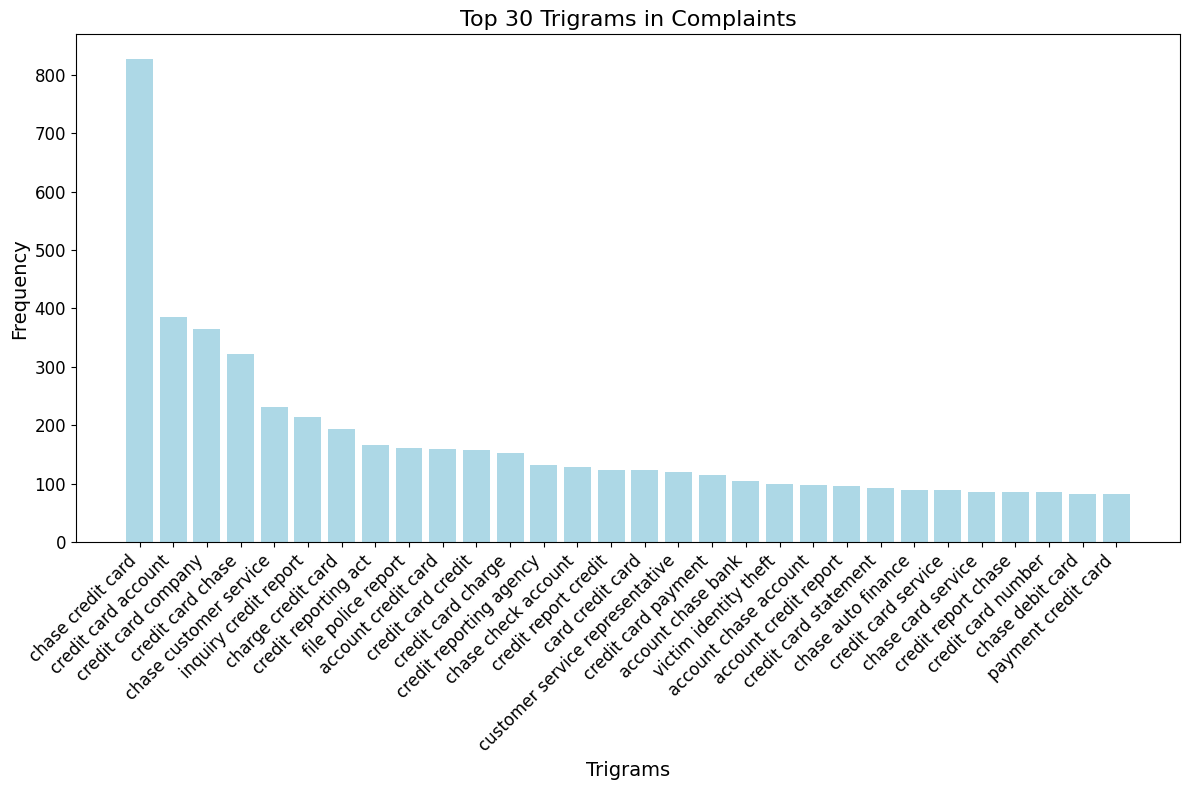

In [ ]:
# Function to get the top n trigrams by frequency
def get_top_n_trigram(corpus, n=None):
    vec = CountVectorizer(stop_words='english', ngram_range=(3, 3)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

common_trigrams = get_top_n_trigram([all_complaints], 30)
df_trigram = pd.DataFrame(common_trigrams, columns=['trigram', 'count'])

plt.figure(figsize=(12, 8))
plt.bar(df_trigram['trigram'], df_trigram['count'], color='lightblue')
plt.xlabel('Trigrams', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Top 30 Trigrams in Complaints', fontsize=16)
plt.xticks(rotation=45, fontsize=12, ha='right')
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

removing 'xxxx xxxx' masked credentials from the data

In [ ]:
processed_df['complaint_cleaned'] = processed_df['complaint_cleaned'].str.replace('xxxx', '')


In [ ]:
all_complaints = ' '.join(processed_df['complaint_cleaned'])
wordcloud_complaints = WordCloud(max_words=50, background_color='white', colormap='viridis',
                      contour_color='steelblue', contour_width=2).generate(all_complaints)

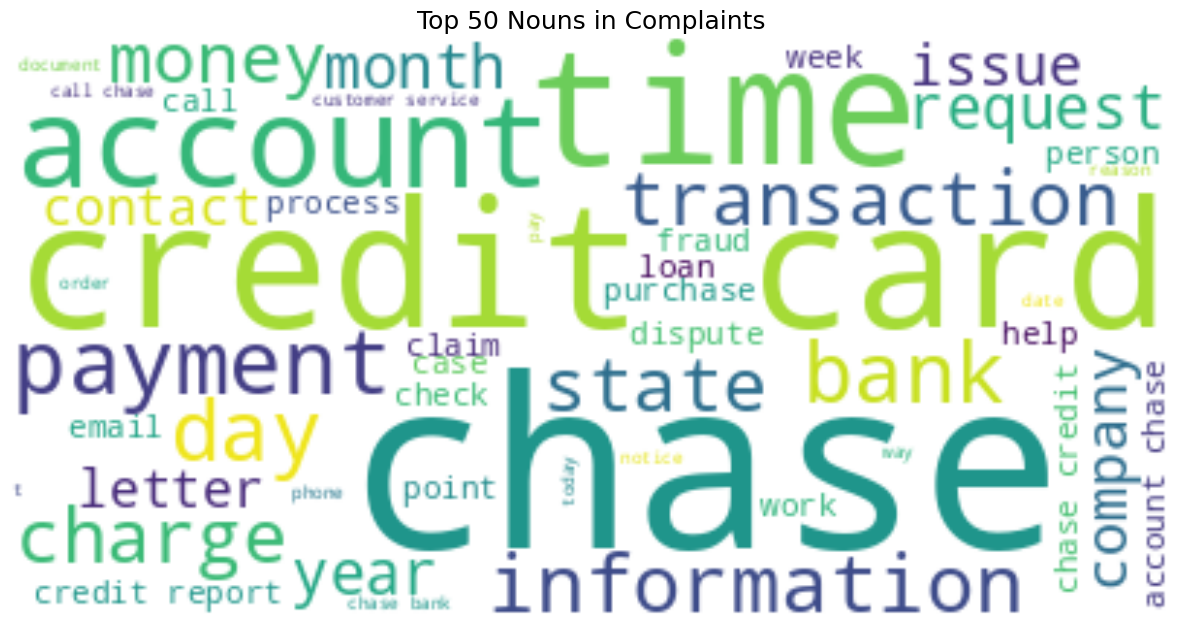

In [ ]:
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud_complaints, interpolation='bilinear')
plt.title('Top 50 Nouns in Complaints', fontsize=18)
plt.axis('off')
plt.show()

Texts to a matrix of TF-IDF features

In [ ]:
tfidf_vect = TfidfVectorizer(stop_words='english', min_df=2, max_df=0.95)

X = tfidf_vect.fit_transform(processed_df['complaint_cleaned'])

In [ ]:
# Document Term Matrix
dtm_df = pd.DataFrame(X.toarray(), columns=tfidf_vect.get_feature_names_out())
dtm_df.head()

aarp  abide  ability  absence  absent  absolve  abuse  abusive  \
0   0.0    0.0      0.0      0.0     0.0      0.0    0.0      0.0   
1   0.0    0.0      0.0      0.0     0.0      0.0    0.0      0.0   
2   0.0    0.0      0.0      0.0     0.0      0.0    0.0      0.0   
3   0.0    0.0      0.0      0.0     0.0      0.0    0.0      0.0   
4   0.0    0.0      0.0      0.0     0.0      0.0    0.0      0.0   

   acceleration  accent  accept  acceptance  access  accessory  accident  \
0           0.0     0.0     0.0         0.0     0.0        0.0       0.0   
1           0.0     0.0     0.0         0.0     0.0        0.0       0.0   
2           0.0     0.0     0.0         0.0     0.0        0.0       0.0   
3           0.0     0.0     0.0         0.0     0.0        0.0       0.0   
4           0.0     0.0     0.0         0.0     0.0        0.0       0.0   

   accommodate  accommodation  accompany  accomplish  accord  accordance  \
0          0.0            0.0        0.0         0.0     0.0         0.0   
1          0.0            0.0        0.0         0.0     0.0         0.0   
2          0.0            0.0        0.0         0.0     0.0         0.0   
3          0.0            0.0        0.0         0.0     0.0         0.0   
4          0.0            0.0        0.0         0.0     0.0         0.0   

    account  accountability  accountant  accounting  accout  accredit  accrue  \
0  0.084427             0.0         0.0         0.0     0.0       0.0     0.0   
1  0.067318             0.0         0.0         0.0     0.0       0.0     0.0   
2  0.000000             0.0         0.0         0.0     0.0       0.0     0.0   
3  0.114750             0.0         0.0         0.0     0.0       0.0     0.0   
4  0.134510             0.0         0.0         0.0     0.0       0.0     0.0   

   acct  accumulate  accumulation  accuracy  accurateness  accure  accusation  \
0   0.0         0.0           0.0       0.0           0.0     0.0         0.0   
1   0.0         0.0           0.0       0.0           0.0     0.0         0.0   
2   0.0         0.0           0.0       0.0           0.0     0.0         0.0   
3   0.0         0.0           0.0       0.0           0.0     0.0         0.0   
4   0.0         0.0           0.0       0.0           0.0     0.0         0.0   

   accuse  ach  acivity  acknowledge  acknowledgement  acknowledgment  acount  \
0     0.0  0.0      0.0          0.0              0.0             0.0     0.0   
1     0.0  0.0      0.0          0.0              0.0             0.0     0.0   
2     0.0  0.0      0.0          0.0              0.0             0.0     0.0   
3     0.0  0.0      0.0          0.0              0.0             0.0     0.0   
4     0.0  0.0      0.0          0.0              0.0             0.0     0.0   

   acquiesce  acquire  acquisition  act  action  activate  activation  \
0        0.0      0.0          0.0  0.0     0.0       0.0         0.0   
1        0.0      0.0          0.0  0.0     0.0       0.0         0.0   
2        0.0      0.0          0.0  0.0     0.0       0.0         0.0   
3        0.0      0.0          0.0  0.0     0.0       0.0         0.0   
4        0.0      0.0          0.0  0.0     0.0       0.0         0.0   

   activity  actor  actuality   ad  adamant  add  addendum  addition  address  \
0       0.0    0.0        0.0  0.0      0.0  0.0       0.0       0.0      0.0   
1       0.0    0.0        0.0  0.0      0.0  0.0       0.0       0.0      0.0   
2       0.0    0.0        0.0  0.0      0.0  0.0       0.0       0.0      0.0   
3       0.0    0.0        0.0  0.0      0.0  0.0       0.0       0.0      0.0   
4       0.0    0.0        0.0  0.0      0.0  0.0       0.0       0.0      0.0   

   adhere  adherence  adjudicate  adjudication  adjust  adjuster  adjustment  \
0     0.0        0.0         0.0           0.0     0.0       0.0         0.0   
1     0.0        0.0         0.0           0.0     0.0       0.0         0.0   
2     0.0        0.0         0.0           0.0 

**Topic Modelling**

Non-Negative Matrix Factorization (NMF) is an unsupervised technique used for topic modeling. Unlike supervised methods, NMF does not require predefined topic labels for training. Instead, it decomposes high-dimensional vectors into a lower-dimensional representation. These lower-dimensional vectors have non-negative coefficients, aiding in the interpretation of topics.

- Determine the optimal number of clusters.
- Utilize the optimal number to generate word clusters.
- Evaluate and validate the relevance of each cluster concerning the given complaints.
- Adjust cluster labels if necessary.
- Associate clusters with specific topics or cluster names for interpretation.

Find the Best Number of Clusters:

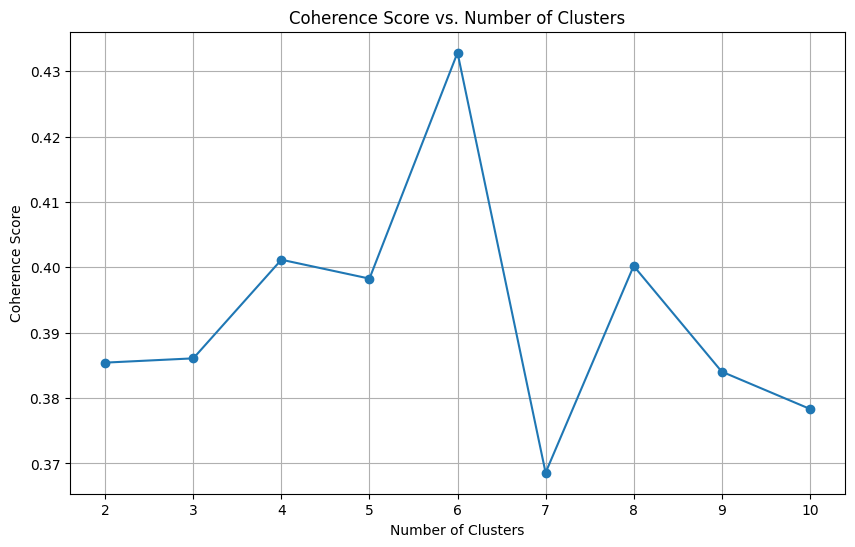

In [ ]:
# Tokenize the cleaned complaints to create the 'texts' list
texts = [doc.split() for doc in processed_df['complaint_cleaned']]

# Proceed with the coherence score calculation
corpus_gensim = gensim.matutils.Sparse2Corpus(X.T)
id_map = dict((v, k) for k, v in tfidf_vect.vocabulary_.items())
dictionary = Dictionary.from_corpus(corpus_gensim, id2word=id_map)

coherence_scores = []
cluster_range = range(2, 11)

for n_clusters in cluster_range:
    nmf_model_gensim = Nmf(corpus=corpus_gensim, num_topics=n_clusters, id2word=dictionary, passes=5)
    cm = CoherenceModel(model=nmf_model_gensim, texts=texts, dictionary=dictionary, coherence='c_v')
    coherence_scores.append(cm.get_coherence())

# Plotting the coherence scores
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, coherence_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Coherence Score')
plt.title('Coherence Score vs. Number of Clusters')
plt.grid(True)
plt.show()

Apply the Best Number to Create Word Clusters

In [ ]:
best_num_clusters = 6

# Fit NMF with the best number of clusters
nmf_model = NMF(n_components=best_num_clusters, random_state=42)
nmf_features = nmf_model.fit_transform(X)

Inspect & Validate Each Cluster with Respect to the Complaints

In [ ]:
# Get the top words in each cluster
def get_top_words_in_cluster(cluster_idx, feature_names, num_top_words=10):
    top_words_idx = nmf_model.components_[cluster_idx].argsort()[:-num_top_words - 1:-1]
    return [feature_names[idx] for idx in top_words_idx]

feature_names = tfidf_vect.get_feature_names_out()

for i in range(best_num_clusters):
    print(f"Cluster {i+1}:")
    top_words = get_top_words_in_cluster(i, feature_names)
    print(top_words)
    print()

Cluster 1:
['chase', 'money', 'transaction', 'claim', 'bank', 'number', 'check', 'day', 'phone', 'contact']

Cluster 2:
['report', 'inquiry', 'credit', 'company', 'identity', 'information', 'reporting', 'theft', 'dispute', 'file']

Cluster 3:
['payment', 'loan', 'mortgage', 'chase', 'month', 'pay', 'year', 'time', 'balance', 'modification']

Cluster 4:
['account', 'check', 'deposit', 'bank', 'fund', 'reason', 'balance', 'money', 'branch', 'business']

Cluster 5:
['card', 'credit', 'chase', 'score', 'purchase', 'limit', 'point', 'year', 'service', 'letter']

Cluster 6:
['charge', 'fee', 'dispute', 'merchant', 'balance', 'transaction', 'purchase', 'overdraft', 'statement', 'chase']



Based on these Clusters, And Top words in each cluster, we will define the following topics to clusters:

- Cluster 1: Bank account services
- Cluster 2: Credit card / Prepaid card
- Cluster 3: Payment Services
- Cluster 4: Others
- Cluster 5: Mortgages/loans
- Cluster 6: Theft/Dispute

In [ ]:
processed_df['Cluster'] = nmf_model.transform(X).argmax(axis=1)

In [ ]:
topic_mapping = {
    0: 'Bank account services',
    1: 'Credit card / Prepaid card',
    2: 'Payment Services',
    3: 'Others',
    4: 'Mortgages/loans',
    5: 'Theft/Dispute'
}


In [ ]:
processed_df['Topic'] = processed_df['Cluster'].map(topic_mapping)

In [ ]:
#assign clusters
processed_df.head()

,complaint_processed,complaint_lemmatized,complaint_nouns,complaint_cleaned,Cluster,Topic
0,good morning my name is xxxx xxxx and i appreciate it if you could help me put a stop to chase bank cardmember services \nin i wrote to chase asking for debt verification and what they sent me a statement which is not acceptable i am asking the bank to validate the debt instead i been receiving mail every month from them attempting to collect a debt \ni have a right to know this information as a consumer \n\nchase account xxxx xxxx xxxx xxxx thanks in advance for your help,good morning xxxx xxxx appreciate help stop chase bank cardmember service \n write chase ask debt verification send statement acceptable ask bank validate debt instead receive mail month attempt collect debt \n right know information consumer \n\n chase account xxxx xxxx xxxx xxxx thank advance help,morning help chase debt verification statement bank validate debt mail month attempt debt information consumer chase account advance help,morning help chase debt verification statement bank validate debt mail month attempt debt information consumer chase account advance help,0,Bank account services
1,i upgraded my xxxx xxxx card in xx xx and was told by the agent who did the upgrade my anniversary date would not change it turned the agent was giving me the wrong information in order to upgrade the account xxxx changed my anniversary date from xx xx xxxx to xx xx xxxx without my consent xxxx has the recording of the agent who was misled me,upgrade xxxx xxxx card xx xx tell agent upgrade anniversary date change turn agent give wrong information order upgrade account xxxx change anniversary date xx xx xxxx xx xx xxxx consent xxxx recording agent mislead,agent anniversary date change agent information order account change anniversary date agent mislead,agent anniversary date change agent information order account change anniversary date agent mislead,3,Others
2,chase card was reported on xx xx however fraudulent application have been submitted my identity without my consent to fraudulently obtain services do not extend credit without verifying the identity of the applicant,chase card report xx xx fraudulent application submit identity consent fraudulently obtain service extend credit verify identity applicant,card application identity consent service credit verify identity applicant,card application identity consent service credit verify identity applicant,4,Mortgages/loans
3,on xx xx while trying to book a xxxx xxxx ticket i came across an offer for to be applied towards the ticket if i applied for a rewards card i put in my information for the offer and within less than a minute was notified via the screen that a decision could not be made i immediately contacted xxxx and was referred to chase bank i then immediately contacted chase bank within no more than of getting the notification on the screen and i was told by the chase representative i spoke with that my application was denied but she could not state why i asked for more information about the xxxx offer and she explained that even if i had been approved the credit offer only gets applied after the first account statement and could not be used to purchase the ticket i then explicitly told her i was glad i got denied and i was absolutely no longer interested in the account i asked that the application be withdrawn and the representative obliged this all happened no later than after putting in the application on xx xx notwithstanding my explicit request not to proceed with the application and contrary to what i was told by the chase representative chase did in fact go ahead to open a credit account in my name on xx xx this is now being reported in my credit report and chase has refused to correct this information on my credit report even though they went ahead to process an application which i did not consent to and out of their error,xx xx try book xxxx xxxx ticket come offer apply ticket apply reward card information o

#### **Supervised Machine Learning for Further Future Complaints Classification**

In [ ]:
data = processed_df[['complaint_cleaned', 'Cluster']]

In [ ]:
data.head()

,complaint_cleaned,Cluster
0,morning help chase debt verification statement bank validate debt mail month attempt debt information consumer chase account advance help,0
1,agent anniversary date change agent information order account change anniversary date agent mislead,3
2,card application identity consent service credit verify identity applicant,4
3,book ticket offer ticket reward card information offer minute screen decision contact chase bank contact chase bank notification screen chase representative speak application state information offer credit offer account statement purchase ticket account application oblige application request application contrary chase representative chase fact credit account report credit report chase information credit report process application consent error,1
4,son deposit chase account fund account pay money son money chase bank money son chase time check owner country time date number claim number chase,0


In [ ]:
X = data['complaint_cleaned']
y = data['Cluster']

In [ ]:
# Convert the target variable into categorical
y = pd.Categorical(y).codes

In [ ]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Vectorize the text data
vectorizer = TfidfVectorizer(max_features=1000)
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [ ]:
#functio to plot confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

##function to train and evaluate a model
def train_eval_model(model, model_name, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    print(f"Classification Report for {model_name}:")
    print(classification_report(y_test, predictions))

    # Calculate accuracy
    accuracy = accuracy_score(y_test, predictions)
    print(f"Accuracy for {model_name}: {accuracy:.4f}")

    # Plotting confusion matrix
    cm = confusion_matrix(y_test, predictions)
    plt.figure()
    plot_confusion_matrix(cm, classes=np.unique(y))
    plt.show()

    # Plotting ROC Curve
    y_bin = label_binarize(y_test, classes=np.unique(y))
    n_classes = y_bin.shape[1]
    y_score = model.predict_proba(X_test)

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure()
    colors = cycle(['blue', 'red', 'green', 'cyan', 'magenta', 'yellow'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of class {0} (area = {1:0.2f})'
                 ''.format(i, roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic for {}'.format(model_name))
    plt.legend(loc="lower right")
    plt.show()

    return accuracy

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.78      0.88      0.83       317
           1       0.96      0.87      0.91       157
           2       0.89      0.93      0.91       275
           3       0.96      0.81      0.87       247
           4       0.85      0.93      0.89       274
           5       0.88      0.77      0.82       177

    accuracy                           0.87      1447
   macro avg       0.89      0.86      0.87      1447
weighted avg       0.88      0.87      0.87      1447

Accuracy for Random Forest: 0.8701


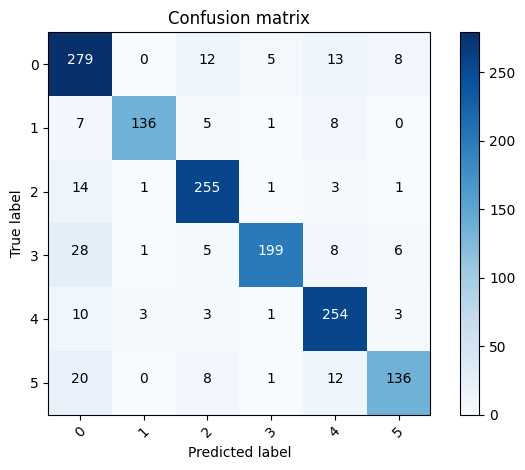

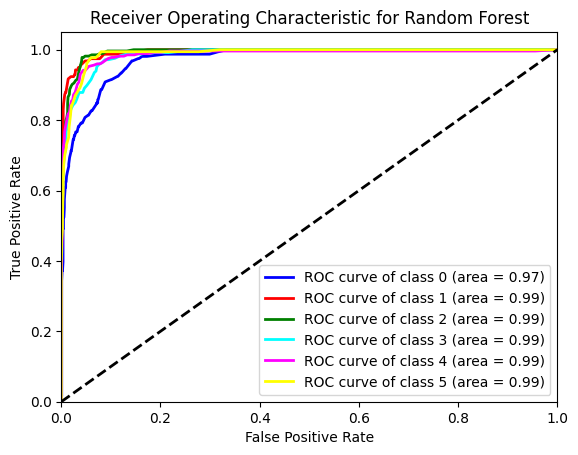

In [ ]:
# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_accuracy = train_eval_model(rf_model, "Random Forest", X_train, y_train, X_test, y_test)

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       317
           1       0.98      0.91      0.94       157
           2       0.95      0.96      0.95       275
           3       0.99      0.92      0.95       247
           4       0.94      0.96      0.95       274
           5       0.94      0.90      0.92       177

    accuracy                           0.94      1447
   macro avg       0.95      0.93      0.94      1447
weighted avg       0.94      0.94      0.94      1447

Accuracy for Logistic Regression: 0.9399


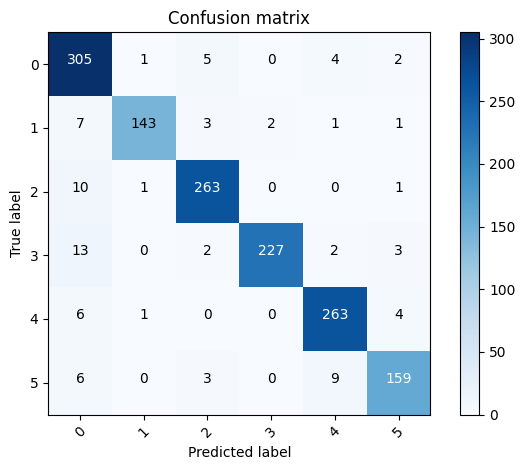

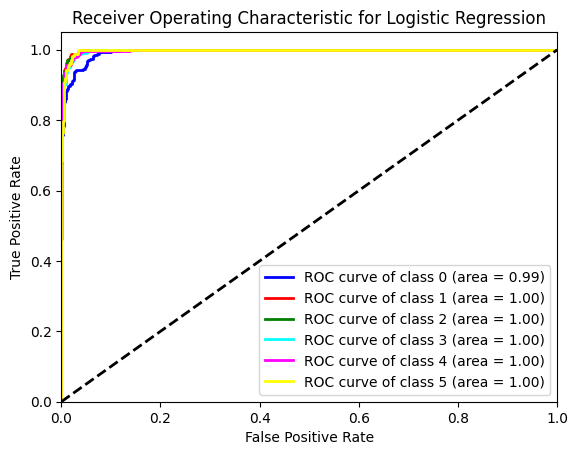

In [ ]:
# Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_accuracy = train_eval_model(lr_model, "Logistic Regression", X_train, y_train, X_test, y_test)

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       317
           1       0.95      0.88      0.91       157
           2       0.95      0.93      0.94       275
           3       0.90      0.91      0.91       247
           4       0.89      0.94      0.91       274
           5       0.88      0.90      0.89       177

    accuracy                           0.90      1447
   macro avg       0.90      0.90      0.90      1447
weighted avg       0.90      0.90      0.90      1447

Accuracy for XGBoost: 0.8991


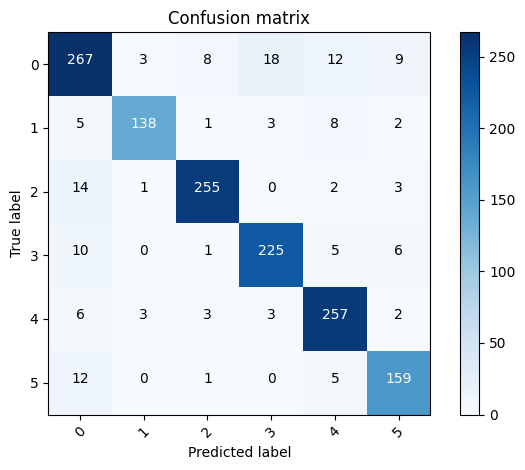

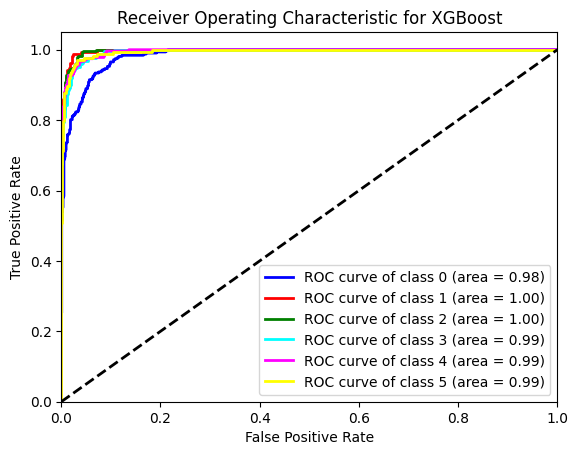

In [ ]:
# XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_accuracy = train_eval_model(xgb_model, "XGBoost", X_train, y_train, X_test, y_test)

In [ ]:
# Compare accuracies and save the best performing model and vectorizer
accuracies = {
    'Random Forest': rf_accuracy,
    'Logistic Regression': lr_accuracy,
    'XGBoost': xgb_accuracy,
}

best_model_name = max(accuracies, key=accuracies.get)
best_overall_accuracy = accuracies[best_model_name]

print(f"The best performing model is {best_model_name} with an accuracy of {best_overall_accuracy:.4f}")

if best_model_name == 'Random Forest':
    final_model = rf_model
elif best_model_name == 'Logistic Regression':
    final_model = lr_model
elif best_model_name == 'XGBoost':
    final_model = xgb_model
elif best_model_name == 'Tuned Logistic Regression':
    final_model = best_lr_model

# Save the best model and the vectorizer
joblib.dump(final_model, 'best_complaint_classifier.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("Best model and TF-IDF vectorizer saved successfully.")

The best performing model is Logistic Regression with an accuracy of 0.9399
Best model and TF-IDF vectorizer saved successfully.


In [ ]:
import re
import logging
from typing import Dict
from transformers import pipeline

logger = logging.getLogger(__name__)
_ZERO_SHOT_PIPELINE = None


def process_complaint(complaint_text: str) -> Dict[str, str]:
    global _ZERO_SHOT_PIPELINE

    if not isinstance(complaint_text, str) or not complaint_text.strip():
        raise ValueError("complaint_text must be a non-empty string.")

    topic_map = globals().get("topic_mapping", {
        0: "Bank account services",
        1: "Credit card / Prepaid card",
        2: "Payment Services",
        3: "Others",
        4: "Mortgages/loans",
        5: "Theft/Dispute",
    })

    model = globals().get("best_model") or globals().get("lr_model") or globals().get("rf_model") or globals().get("xgb_model")
    if model is None or "vectorizer" not in globals():
        raise RuntimeError("Model/vectorizer missing. Run training cells first.")

    # Preprocess text
    if "preprocess_text" in globals() and callable(preprocess_text):
        cleaned = preprocess_text(complaint_text)
    else:
        cleaned = complaint_text.lower()
        cleaned = re.sub(r"\[.*?\]", " ", cleaned)
        cleaned = re.sub(r"[^\w\s]", " ", cleaned)
        cleaned = re.sub(r"\w*\d\w*", " ", cleaned).strip()

    text_l = complaint_text.lower()

    # -------- 1) Category (rule-first override for theft/fraud) --------
    theft_patterns = [
        r"\bstolen\b",
        r"\bunauthori[sz]ed\b",
        r"\bfraud\b",
        r"\bcard (was )?stolen\b",
        r"\bunfamiliar transactions?\b",
        r"\bidentity theft\b",
        r"\bchargeback\b",
        r"\bdispute\b",
        r"\bcard compromised\b",
        r"\baccount drained\b",
    ]

    if any(re.search(p, text_l) for p in theft_patterns):
        category = "Theft/Dispute"
    else:
        vec = vectorizer.transform([cleaned])
        cluster_id = int(model.predict(vec)[0])
        category = topic_map.get(cluster_id, "Others")

        # Low confidence guard
        if hasattr(model, "predict_proba"):
            conf = float(model.predict_proba(vec).max())
            if conf < 0.35:
                category = "Others"

    # -------- 2) Root Cause --------
    root_cause_candidates = {
        "Bank account services": [
            "Account access/login issue",
            "Unexpected account freeze or hold",
            "Incorrect account fee/charge",
            "KYC/verification delay",
            "Customer support communication gap",
        ],
        "Credit card / Prepaid card": [
            "Card declined despite available limit",
            "Hidden fee or interest charge",
            "Billing statement error",
            "Card activation/replacement delay",
            "Unauthorized card transaction",
        ],
        "Payment Services": [
            "Transfer/payment processing failure",
            "Delayed payment settlement",
            "Duplicate transaction",
            "Refund not received",
            "Wrong beneficiary or routing issue",
        ],
        "Mortgages/loans": [
            "EMI/payment posting issue",
            "Loan servicing communication failure",
            "Unexpected penalty or interest adjustment",
            "Foreclosure/default handling dispute",
            "Loan modification delay",
        ],
        "Theft/Dispute": [
            "Card or account compromised",
            "Unauthorized transaction/fraud",
            "Identity theft suspicion",
            "Chargeback/dispute not resolved",
            "Delayed fraud response",
        ],
        "Others": [
            "General service quality issue",
            "Policy/terms misunderstanding",
            "Documentation/process delay",
            "Unclear communication from bank",
            "Other non-specific banking issue",
        ],
    }

    # Hard override for obvious stolen/unauthorized card complaint
    if category == "Theft/Dispute" and re.search(r"\b(card|credit|debit)\b", text_l) and re.search(r"\b(stolen|unauthori[sz]ed|fraud)\b", text_l):
        root_cause = "Unauthorized transaction/fraud"
    else:
        labels = root_cause_candidates.get(category, root_cause_candidates["Others"])

        if _ZERO_SHOT_PIPELINE is None:
            try:
                _ZERO_SHOT_PIPELINE = pipeline(
                    "zero-shot-classification",
                    model="facebook/bart-large-mnli",
                    truncation=True
                )
            except Exception as e:
                logger.exception("Failed to load zero-shot pipeline: %s", e)
                _ZERO_SHOT_PIPELINE = "UNAVAILABLE"

        if _ZERO_SHOT_PIPELINE != "UNAVAILABLE":
            result = _ZERO_SHOT_PIPELINE(
                complaint_text,
                candidate_labels=labels,
                multi_label=False,
                hypothesis_template="The main root cause is {}."
            )
            root_cause = result["labels"][0]
        else:
            root_cause = labels[0]

    # -------- 3) Priority --------
    high_risk_pattern = re.compile(
        r"\b(theft|fraud|unauthori[sz]ed|stolen|scam|hacked|identity theft|dispute|chargeback|"
        r"foreclosure|eviction|lost money|financial loss|account drained)\b",
        flags=re.IGNORECASE,
    )
    low_risk_pattern = re.compile(
        r"\b(inquiry|question|clarification|information|status update|feedback)\b",
        flags=re.IGNORECASE,
    )

    if category == "Theft/Dispute" or high_risk_pattern.search(complaint_text):
        priority = "High"
    elif low_risk_pattern.search(complaint_text):
        priority = "Low"
    else:
        priority = "Medium"

    return {
        "category": category,
        "root_cause": root_cause,
        "priority": priority,
    }


In [ ]:
# Test cell
user_complaint = input("Enter a customer complaint: ").strip()

if not user_complaint:
    print("Please enter a non-empty complaint.")
else:
    result = process_complaint(user_complaint)
    print("\nComplaint Analysis")
    print("-" * 30)
    print(f"Category   : {result['category']}")
    print(f"Root Cause : {result['root_cause']}")
    print(f"Priority   : {result['priority']}")


Enter a customer complaint: i upgraded my xxxx xxxx card in xx xx and was told by the agent who did the upgrade my anniversary date would not change it turned the agent was giving me the wrong information in order to upgrade the account xxxx changed my anniversary date from xx xx xxxx to xx xx xxxx without my consent xxxx has the recording of the agent who was misled me


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Complaint Analysis
------------------------------
Category   : Others
Root Cause : Unclear communication from bank
Priority   : Low
